In [1]:
# This Python 3 environment comes with many helpful analytics libraries installed
# It is defined by the kaggle/python Docker image: https://github.com/kaggle/docker-python
# For example, here's several helpful packages to load

import numpy as np # linear algebra
import pandas as pd # data processing, CSV file I/O (e.g. pd.read_csv)

# Input data files are available in the read-only "../input/" directory
# For example, running this (by clicking run or pressing Shift+Enter) will list all files under the input directory

import os
for dirname, _, filenames in os.walk('/kaggle/input'):
    for filename in filenames:
        print(os.path.join(dirname, filename))

# You can write up to 20GB to the current directory (/kaggle/working/) that gets preserved as output when you create a version using "Save & Run All" 
# You can also write temporary files to /kaggle/temp/, but they won't be saved outside of the current session

/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/sample_submission.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/train.csv
/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/test.csv


In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

from sklearn.compose import make_column_selector as selector
from sklearn.preprocessing import StandardScaler, MinMaxScaler, OrdinalEncoder, OneHotEncoder
from sklearn.impute import SimpleImputer, KNNImputer
from sklearn.pipeline import Pipeline
from sklearn.compose import ColumnTransformer
from sklearn.model_selection import GridSearchCV, RandomizedSearchCV, train_test_split, cross_val_score
from sklearn.decomposition import PCA
from sklearn.feature_selection import SelectKBest, f_regression, SequentialFeatureSelector
from sklearn.linear_model import LinearRegression, SGDRegressor, Lasso, Ridge, LassoCV, RidgeCV
from sklearn.ensemble import RandomForestRegressor, RandomForestClassifier
from sklearn.tree import DecisionTreeRegressor
from sklearn.neighbors import KNeighborsRegressor
from sklearn.svm import SVR, SVC
from sklearn.metrics import (
    mean_squared_error, r2_score, mean_absolute_error,
    accuracy_score, precision_score, recall_score,
    f1_score, classification_report, confusion_matrix, roc_auc_score
)
from sklearn.datasets import make_classification


In [3]:
train_data=pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/train.csv')
test_data=pd.read_csv('/kaggle/input/mlp-term-2-2025-kaggle-assignment-3/test.csv')
test_data.head()

,id,store_name,category,store_address,latitude,longitude,rating_count,review_time,review
0,0,McDonald's,Fast food restaurant,"8500 US-290, Austin, TX 78724, United States",30.329135,-97.660629,"1,406",2 years ago,The kids love be the Bigfries and The Check in...
1,1,McDonald's,Fast food restaurant,"1415 E State Rd, Fern Park, FL 32730, United S...",28.655350,-81.342692,"1,618",4 years ago,Excellent
2,2,McDonald's,Fast food restaurant,"490 8th Ave, New York, NY 10001, United States",40.752529,-73.992876,"3,902",6 years ago,No change on food standard from other Mac rest...
3,3,McDonald's,Fast food restaurant,"5725 W Irlo Bronson Memorial Hwy, Kissimmee, F...",28.333508,-81.513738,"5,567",a year ago,John was great and super friendly everyone els...
4,4,McDonald's,Fast food restaurant,"72-69 Kissena Blvd, Queens, NY 11367, United S...",40.727401,-73.812460,"2,193",6 years ago,Strange drive thru entrance; quick service. Pa...


In [4]:
print("train_data shape",train_data.shape)
print("test_data shape",test_data.shape)

train_data shape (26500, 10)
test_data shape (7000, 9)


# RUBRICS 1 - Identify data types of different columns

In [5]:
train_data.columns

Index(['id', 'store_name', 'category', 'store_address', 'latitude ',
       'longitude', 'rating_count', 'review_time', 'review', 'rating'],
      dtype='object')

In [5]:
# Remove leading/trailing whitespaces from all column names
train_data.columns = train_data.columns.str.strip()
test_data.columns = test_data.columns.str.strip()

In [6]:
train_data=train_data.map(lambda x: x.strip() if isinstance (x,str) else x)
test_data=test_data.map(lambda x: x.strip() if isinstance (x,str) else x)

In [13]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26500 entries, 0 to 26499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             26500 non-null  int64  
 1   store_name     26500 non-null  object 
 2   category       26500 non-null  object 
 3   store_address  26500 non-null  object 
 4   latitude       25976 non-null  float64
 5   longitude      25976 non-null  float64
 6   rating_count   26500 non-null  object 
 7   review_time    26500 non-null  object 
 8   review         26500 non-null  object 
 9   rating         26500 non-null  int64  
dtypes: float64(2), int64(2), object(6)
memory usage: 2.0+ MB


In [14]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             7000 non-null   int64  
 1   store_name     7000 non-null   object 
 2   category       7000 non-null   object 
 3   store_address  7000 non-null   object 
 4   latitude       6864 non-null   float64
 5   longitude      6864 non-null   float64
 6   rating_count   7000 non-null   object 
 7   review_time    7000 non-null   object 
 8   review         7000 non-null   object 
dtypes: float64(2), int64(1), object(6)
memory usage: 492.3+ KB


# RUBRICS 2 - Present descriptive statistics of numerical columns

In [8]:
train_data[['latitude', 'longitude']].describe(include='all')

,latitude,longitude
count,25976.000000,25976.000000
mean,34.427152,-90.659226
std,5.336112,16.588603
min,25.790295,-121.995421
25%,28.655350,-97.792874
50%,33.931261,-81.471414
75%,40.727401,-75.399919
max,44.981410,-73.459820


# RUBRICS 3 - Identify and handle the missing values

In [9]:
train_data.isnull().sum()

id                 0
store_name         0
category           0
store_address      0
latitude         524
longitude        524
rating_count       0
review_time        0
review             0
rating             0
dtype: int64

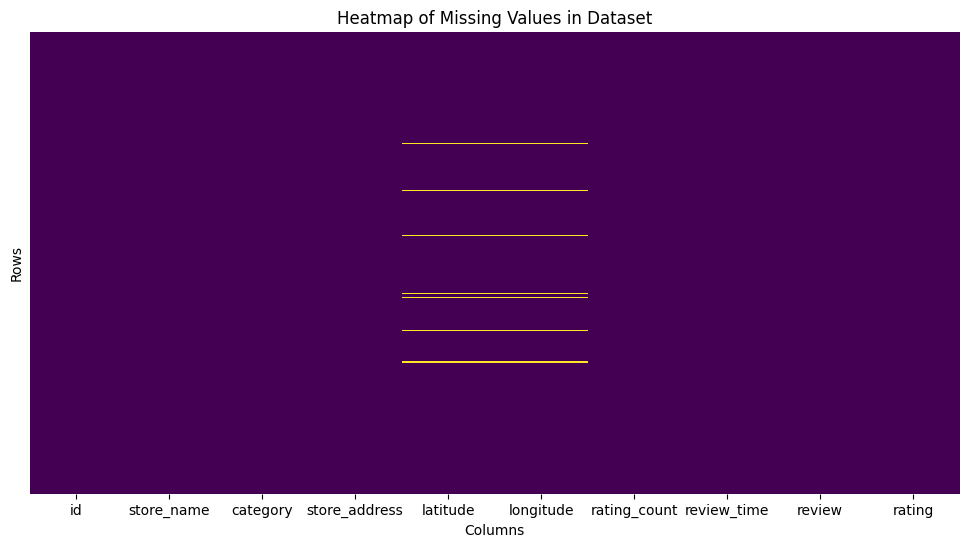

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

# Set plot size and style
plt.figure(figsize=(12, 6))
sns.heatmap(train_data.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# Plot title and axis labels
plt.title('Heatmap of Missing Values in Dataset')
plt.xlabel('Columns')
plt.ylabel('Rows')

plt.show()

In [10]:
test_data.isnull().sum()

id                 0
store_name         0
category           0
store_address      0
latitude         136
longitude        136
rating_count       0
review_time        0
review             0
dtype: int64

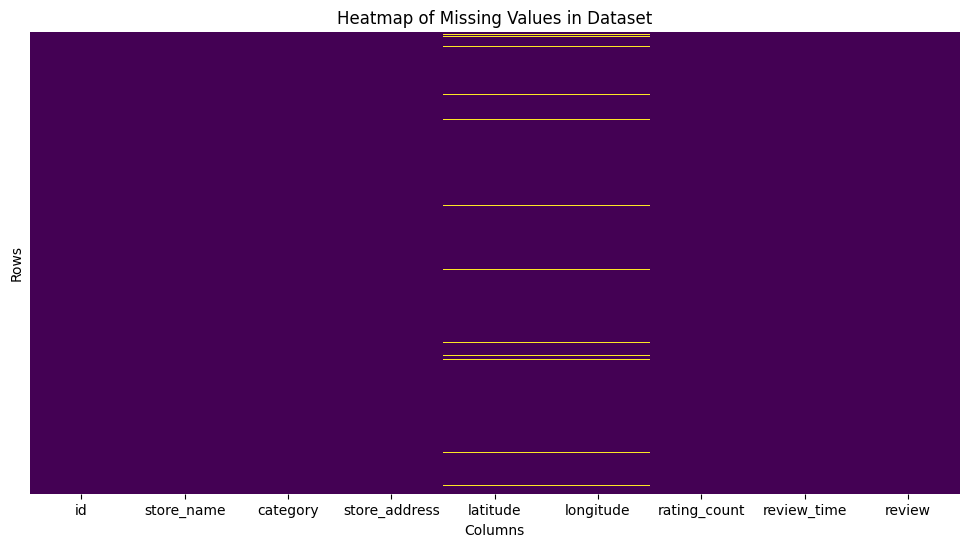

In [11]:
plt.figure(figsize=(12, 6))
sns.heatmap(test_data.isnull(), cbar=False, cmap='viridis', yticklabels=False)

# Plot title and axis labels
plt.title('Heatmap of Missing Values in Dataset')
plt.xlabel('Columns')
plt.ylabel('Rows')

plt.show()

# RUBRICS 4 - Identify and handle duplicates

In [16]:
train_data.duplicated().sum()

0

In [17]:
test_data.duplicated().sum()

0

# RUBRICS 5 - Identify and handle outliers

In [20]:
def detect_outliers_iqr(df, column):
    Q1 = df[column].quantile(0.25)
    Q3 = df[column].quantile(0.75)
    IQR = Q3 - Q1
    lower_bound = Q1 - 1.5 * IQR
    upper_bound = Q3 + 1.5 * IQR
    return df[(df[column] < lower_bound) | (df[column] > upper_bound)]

# Detect outliers
outliers_lat = detect_outliers_iqr(train_data, 'latitude')
outliers_long = detect_outliers_iqr(train_data, 'longitude')

print(f"Latitude outliers: {len(outliers_lat)}")
print(f"Longitude outliers: {len(outliers_long)}")

Latitude outliers: 0
Longitude outliers: 0


# RUBRICS 6 - Present at least three visualizations and provide insights for the same

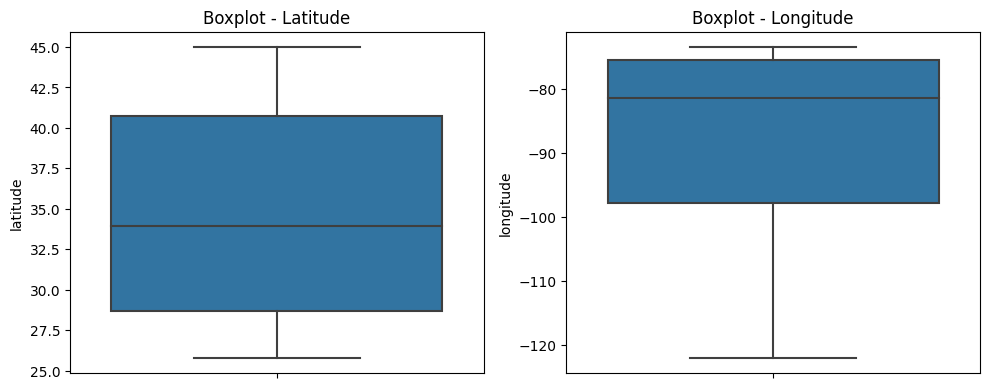

In [19]:
import matplotlib.pyplot as plt
import seaborn as sns

# Plot boxplots
plt.figure(figsize=(10, 4))

plt.subplot(1, 2, 1)
sns.boxplot(y=train_data['latitude'])
plt.title('Boxplot - Latitude')

plt.subplot(1, 2, 2)
sns.boxplot(y=train_data['longitude'])
plt.title('Boxplot - Longitude')

plt.tight_layout()
plt.show()

In [21]:
train_data.store_name.unique()

array(["McDonald's", "ýýýMcDonald's"], dtype=object)

In [22]:
train_data['store_name'] = train_data['store_name'].replace("ýýýMcDonald's", "McDonald's")
train_data['store_name']=train_data['store_name'].replace("McDonald's",1)

In [23]:
test_data['store_name'] = test_data['store_name'].replace("ýýýMcDonald's", "McDonald's")
test_data['store_name']=test_data['store_name'].replace("McDonald's",1)

In [15]:
train_data['store_name'].value_counts()

store_name
1    26500
Name: count, dtype: int64

In [16]:
train_data['category'].unique()

array(['Fast food restaurant'], dtype=object)

In [24]:
train_data['category']=train_data['category'].replace("Fast food restaurant",1)

In [25]:
test_data['category']=test_data['category'].replace("Fast food restaurant",1)

In [19]:
train_data['category'].value_counts()

category
1    26500
Name: count, dtype: int64

In [7]:
train_data['latitude'] = train_data['latitude'].fillna(train_data['latitude'].mean())
train_data['longitude'] = train_data['longitude'].fillna(train_data['longitude'].mean())

In [8]:
test_data['latitude'] = test_data['latitude'].fillna(test_data['latitude'].mean())
test_data['longitude'] = test_data['longitude'].fillna(test_data['longitude'].mean())

In [23]:
train_data.columns

Index(['id', 'store_name', 'category', 'store_address', 'latitude',
       'longitude', 'rating_count', 'review_time', 'review', 'rating'],
      dtype='object')

In [9]:
# Remove commas and convert to integer
train_data['rating_count'] = train_data['rating_count'].str.replace(',', '').astype(int)

In [10]:
test_data['rating_count'] = test_data['rating_count'].str.replace(',', '').astype(int)

In [117]:
train_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 26500 entries, 0 to 26499
Data columns (total 10 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             26500 non-null  int64  
 1   store_name     26500 non-null  object 
 2   category       26500 non-null  object 
 3   store_address  26500 non-null  object 
 4   latitude       26500 non-null  float64
 5   longitude      26500 non-null  float64
 6   rating_count   26500 non-null  int64  
 7   review_time    26500 non-null  object 
 8   review         26500 non-null  object 
 9   rating         26500 non-null  int64  
dtypes: float64(2), int64(3), object(5)
memory usage: 2.0+ MB


In [34]:
test_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7000 entries, 0 to 6999
Data columns (total 9 columns):
 #   Column         Non-Null Count  Dtype  
---  ------         --------------  -----  
 0   id             7000 non-null   int64  
 1   store_name     7000 non-null   int64  
 2   category       7000 non-null   int64  
 3   store_address  7000 non-null   object 
 4   latitude       7000 non-null   float64
 5   longitude      7000 non-null   float64
 6   rating_count   7000 non-null   int64  
 7   review_time    7000 non-null   object 
 8   review         7000 non-null   object 
dtypes: float64(2), int64(4), object(3)
memory usage: 492.3+ KB


In [11]:
y=train_data['rating']
y.head()

0    5
1    5
2    1
3    1
4    1
Name: rating, dtype: int64

In [19]:
y.value_counts()

rating
5    8150
1    7491
4    4592
3    3819
2    2448
Name: count, dtype: int64

In [12]:
X_data=train_data.drop(columns=['id','store_name','category','store_address','review_time', 'rating'],axis=1)
test_data=test_data.drop(columns=['id','store_name','category','store_address','review_time'],axis=1)

In [151]:
X_data.head()

,latitude,longitude,rating_count,review
0,28.423814,-81.461242,5468,"Very nice staff, good place to get all your fa..."
1,33.009318,-97.222925,998,"I think the morning shift are one of, if not t..."
2,40.752529,-73.992876,3902,Horrible! Avoid this place at night. Unsafe. ...
3,41.879656,-87.777913,1454,Employees too busy window licking to get any o...
4,28.333508,-81.513738,5566,I'm sorry to give only one star. But during ou...


from sklearn.compose import ColumnTransformer
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.preprocessing import StandardScaler, OneHotEncoder

preprocessor = ColumnTransformer(
    transformers=[
        ('text', TfidfVectorizer(max_features=5000, ngram_range=(1,2)), ['review'])])

In [16]:
X_data.corr(numeric_only=True)

,latitude,longitude,rating_count
latitude,1.000000,0.145838,-0.346372
longitude,0.145838,1.000000,0.127831
rating_count,-0.346372,0.127831,1.000000


<Axes: >

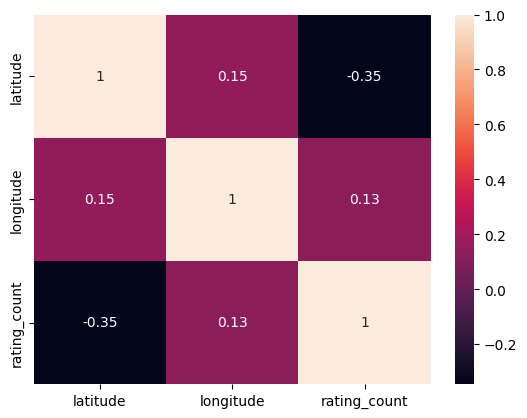

In [18]:
sns.heatmap(X_data.corr(numeric_only=True),annot=True)

In [19]:
test_data.corr(numeric_only=True)

,latitude,longitude,rating_count
latitude,1.000000,0.142239,-0.330736
longitude,0.142239,1.000000,0.121557
rating_count,-0.330736,0.121557,1.000000


<Axes: >

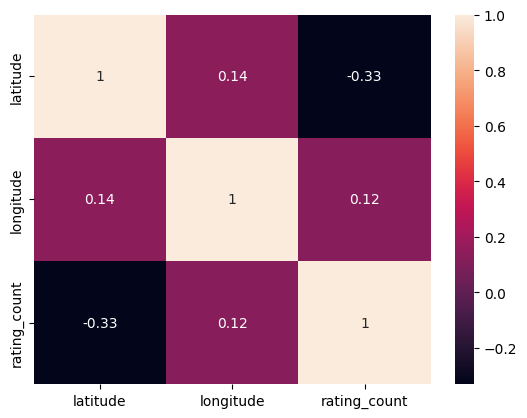

In [20]:
sns.heatmap(test_data.corr(numeric_only=True),annot=True)

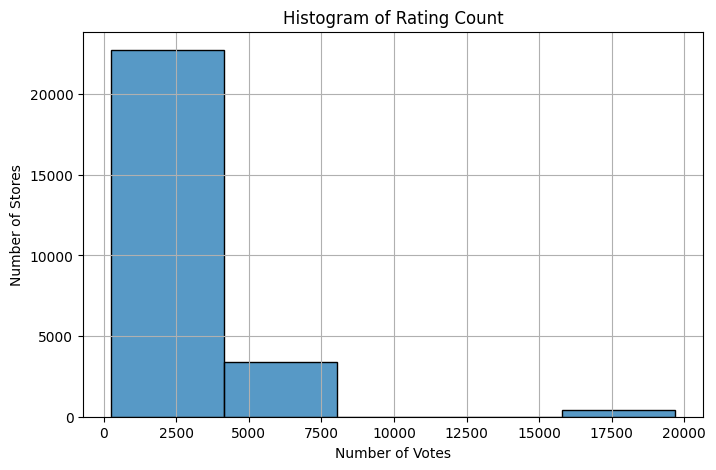

In [42]:
import matplotlib.pyplot as plt
import seaborn as sns

# Convert rating_count to numeric (remove commas and convert to int)
#train_data['rating_count'] = train_data['rating_count'].str.replace(',', '').astype(int)

# Plot histogram with 15 bins
plt.figure(figsize=(8, 5))
sns.histplot(train_data['rating_count'], bins=5, kde=False)
plt.title('Histogram of Rating Count')
plt.xlabel('Number of Votes')
plt.ylabel('Number of Stores')
plt.grid(True)
plt.show()

# RUBRICS 7 - Scale Numerical features and Encode Categorical features

In [16]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X_data,y,test_size=0.10,stratify=y,random_state=2)

In [17]:
print(X_train.shape)
print(y_train.shape)
print(X_test.shape)
print(y_test.shape)

(23850, 4)
(23850,)
(2650, 4)
(2650,)


In [18]:
y_train.head()

6717     5
26004    1
9702     1
24732    4
13818    2
Name: rating, dtype: int64

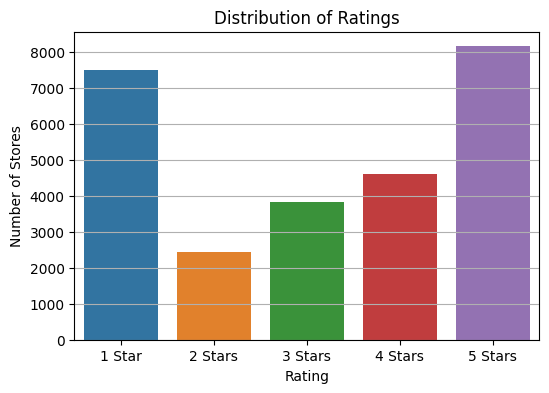

In [26]:
# Plot count of ratings
plt.figure(figsize=(6, 4))
sns.countplot(x='rating', data=train_data)

# Set x and y tick labels clearly
plt.xticks([0, 1, 2, 3, 4], ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars'])
plt.yticks(rotation=0)
plt.xlabel('Rating')
plt.ylabel('Number of Stores')
plt.title('Distribution of Ratings')
plt.grid(axis='y')
plt.show()

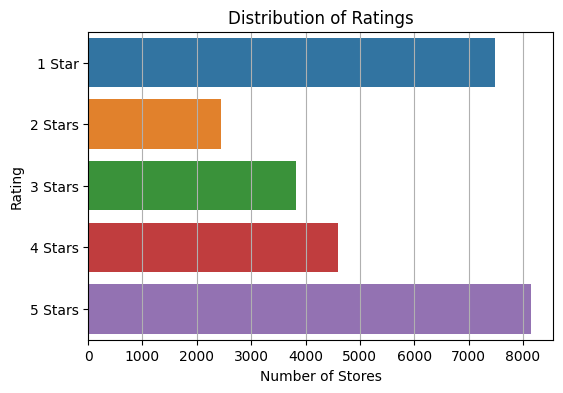

In [27]:
# Horizontal bar plot
plt.figure(figsize=(6, 4))
sns.countplot(y='rating', data=train_data)

# Set y tick labels
plt.yticks([0, 1, 2, 3, 4], ['1 Star', '2 Stars', '3 Stars', '4 Stars', '5 Stars'])
plt.xlabel('Number of Stores')
plt.ylabel('Rating')
plt.title('Distribution of Ratings')
plt.grid(axis='x')
plt.show()

In [20]:
y.value_counts()

rating
5    8150
1    7491
4    4592
3    3819
2    2448
Name: count, dtype: int64

In [16]:
test_data.head()

,latitude,longitude,rating_count,review
0,30.329135,-97.660629,1406,The kids love be the Bigfries and The Check in...
1,28.655350,-81.342692,1618,Excellent
2,40.752529,-73.992876,3902,No change on food standard from other Mac rest...
3,28.333508,-81.513738,5567,John was great and super friendly everyone els...
4,40.727401,-73.812460,2193,Strange drive thru entrance; quick service. Pa...


In [21]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.naive_bayes import MultinomialNB
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

# Define numerical and text features
numerical_features = ['latitude', 'longitude', 'rating_count']
text_features = 'review'

# Create preprocessing pipelines for numerical and text features
numerical_transformer = MinMaxScaler()
text_transformer = TfidfVectorizer(stop_words='english', max_features=10000,token_pattern=r'[a-zA-Z]+')

# Create a column transformer to apply different transformations to different columns
preprocessor = ColumnTransformer(
    transformers=[
        ('num', numerical_transformer, numerical_features),
        ('txt', text_transformer, text_features)
    ],
    remainder='passthrough' # Keep other columns as is
)

# Create a pipeline that includes preprocessing and the classifier
model = Pipeline(steps=[('preprocessor', preprocessor),
                        ('classifier', MultinomialNB())])

# Train the model
model.fit(X_train, y_train)

Pipeline(steps=[('preprocessor',
                 ColumnTransformer(remainder='passthrough',
                                   transformers=[('num', MinMaxScaler(),
                                                  ['latitude', 'longitude',
                                                   'rating_count']),
                                                 ('txt',
                                                  TfidfVectorizer(max_features=10000,
                                                                  stop_words='english',
                                                                  token_pattern='[a-zA-Z]+'),
                                                  'review')])),
                ('classifier', MultinomialNB())])

# MultinomialNB Model

In [22]:
from sklearn.metrics import classification_report
y_pred = model.predict(X_test)
print(classification_report(y_test, y_pred))

              precision    recall  f1-score   support

           1       0.60      0.94      0.74       749
           2       0.96      0.11      0.19       245
           3       0.84      0.28      0.42       382
           4       0.78      0.30      0.43       459
           5       0.62      0.88      0.73       815

    accuracy                           0.64      2650
   macro avg       0.76      0.50      0.50      2650
weighted avg       0.71      0.64      0.59      2650



# RUBRICS 8 - Model Building (at least 7)

In [23]:
from sklearn.preprocessing import OneHotEncoder, StandardScaler
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.svm import SVC
from sklearn.neighbors import KNeighborsClassifier
from sklearn.naive_bayes import GaussianNB
from sklearn.neural_network import MLPClassifier
from sklearn.metrics import classification_report

# Example feature groups
numerical_features = ['latitude', 'longitude', 'rating_count']
categorical_features = ['review']  # example categorical cols
text_feature = 'review'

# Preprocessors
num_transformer = MinMaxScaler()
cat_transformer = OneHotEncoder(handle_unknown='ignore')
text_transformer = TfidfVectorizer(stop_words='english', max_features=5000, token_pattern=r'[a-zA-Z]+')

# Column transformer
preprocessor = ColumnTransformer(
    transformers=[
        ('num', num_transformer, numerical_features),
        ('txt', text_transformer, text_feature),
        ('cat', cat_transformer, categorical_features) ])
models = {
    "Decision Tree": DecisionTreeClassifier(),
    "Gradient Boosting": GradientBoostingClassifier(),
    "K-Nearest Neighbors": KNeighborsClassifier(),
    "SVC": SVC(),
    "MLP Classifier": MLPClassifier(max_iter=100),
    "Logistic Regression": LogisticRegression(max_iter=500),
    "Random Forest": RandomForestClassifier(),
    #"Gaussian NB": GaussianNB()  # Needs dense input
}

for name, clf in models.items():
    print("="*60)
    print(f"Model: {name}")
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)
    ])
    model_pipeline.fit(X_train, y_train)
    y_pred = model_pipeline.predict(X_test)
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

Model: Decision Tree
Classification Report:
              precision    recall  f1-score   support

           1       0.72      0.73      0.72       749
           2       0.48      0.43      0.45       245
           3       0.57      0.49      0.52       382
           4       0.56      0.51      0.54       459
           5       0.68      0.77      0.72       815

    accuracy                           0.64      2650
   macro avg       0.60      0.59      0.59      2650
weighted avg       0.63      0.64      0.64      2650

Model: Gradient Boosting
Classification Report:
              precision    recall  f1-score   support

           1       0.55      0.93      0.69       749
           2       0.65      0.14      0.23       245
           3       0.72      0.36      0.48       382
           4       0.67      0.33      0.44       459
           5       0.68      0.77      0.72       815

    accuracy                           0.62      2650
   macro avg       0.65      0.50      

# RUBRICS 9 - Hyperparameter Tuning on any 3 of the models

In [34]:
from sklearn.model_selection import RandomizedSearchCV, GridSearchCV
from sklearn.metrics import accuracy_score, classification_report
import numpy as np

# 1. Random Forest
from sklearn.ensemble import RandomForestClassifier
rf_params = {
    'n_estimators': [100, 200, 300],         # Number of trees
    'max_depth': [None, 10, 20, 30, 50],     # Tree depth
    'min_samples_split': [2, 5, 10],         # Min samples to split a node
    'min_samples_leaf': [1, 2, 4],           # Min samples at a leaf node
    'max_features': ['sqrt', 'log2', None],  # Features considered for split
    'bootstrap': [True, False],              # Bootstrap sampling
    'class_weight': [None, 'balanced']       # Handle imbalance
}
rf_model = RandomForestClassifier(random_state=42)
rf_search = GridSearchCV(rf_model, rf_params, cv=3, scoring='accuracy', n_jobs=-1)

#2 Logistic Regressions
log_reg_params = {
    'penalty': ['l1', 'l2', 'elasticnet', None],  # Regularization type
    'C': [0.01, 0.1, 1, 10, 100],  # Inverse of regularization strength
    'solver': ['lbfgs', 'liblinear', 'saga'],  # saga supports elasticnet
    'max_iter': [100, 200],
    'l1_ratio': [0, 0.5, 1]  # Only for elasticnet
}
log_model=LogisticRegression()
log_search=GridSearchCV(log_model,log_reg_params,cv=5,scoring='f1_macro',n_jobs=-1)

#3 MLPCLASSIFIER
#mlp_params = {
  #'hidden_layer_sizes': [(50,), (100,), (100, 50), (128, 64, 32)],  # Architecture
 #   'activation': ['relu', 'tanh'],
  #  'solver': ['adam', 'lbfgs'],  # 'lbfgs' good for small datasets
   # 'alpha': [0.0001, 0.001, 0.01],  # L2 regularization
    #'learning_rate': ['constant', 'adaptive'],
    #'max_iter': [50, 1000],
    #'early_stopping': [True]  # Avoids overfitting}
#}
#mlp_model=MLPClassifier()
#mlp_search=RandomizedSearchCV(mlp_model,mlp_params,cv=5,n_jobs=-1)

# 4. Gradient Boosting
#from sklearn.ensemble import GradientBoostingClassifier
#gb_params = {
 #   'n_estimators': [50, 100, 150],
  #  'learning_rate': [0.01, 0.05, 0.1],
   # 'max_depth': [3, 5, 7]}
#gb_model = GradientBoostingClassifier(random_state=42)
#gb_search = RandomizedSearchCV(gb_model, gb_params, n_iter=10, cv=3, scoring='accuracy', n_jobs=-1, random_state=42)



In [ ]:
tuned_models = {
    'Random Forest': rf_search,
    'Logistic Regression': log_search,
    #'MLP Classifier': mlp_search,
}

for name, clf in tuned_models.items():
    print("="*60)
    print(f"Tuning Model: {name}")
    model_pipeline = Pipeline(steps=[
        ('preprocessor', preprocessor),
        ('classifier', clf)])
    model_pipeline.fit(X_train, y_train)  
    best_model=model_pipeline.best_estimator_
    y_pred = best_model.predict(X_test)

    print(f"Best Params: {model.best_params_}")
    print('accuracy score', accuracy_score(y_test, y_pred))
    print("Classification Report:")
    print(classification_report(y_test, y_pred))

Tuning Model: Random Forest


# RUBRICS 10 - Comparison of model performances

In [24]:
#model = Pipeline(steps=[('preprocessor', preprocessor),
                        #('classifier', MultinomialNB())])
test_pred = model.predict(test_data)
#test_pred = model_pipeline.predict(test_data)
test_pred=np.clip(test_pred, 0, None)

In [25]:
submission = pd.DataFrame({
    "id": range(test_data.shape[0]),
    "rating": test_pred
})
submission.to_csv("submission.csv", index=False)
submission

,id,rating
0,0,5
1,1,5
2,2,1
3,3,5
4,4,4
...,...,...
6995,6995,5
6996,6996,4
6997,6997,5
6998,6998,5
